In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
assert project_root.name == "digital-twin-lite", f"Root salah: {project_root}"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd

In [2]:
from src.generate_fault_data import FaultConfig, generate_fault_sensor_log_csv

fault = FaultConfig(
    fault_start_s=350.0,
    fault_type="liquid_restriction",
    severity_final=0.5
)

fault_path = generate_fault_sensor_log_csv(
    out_relpath="data/raw/sensor_log_fault.csv",
    seed=7,
    make_folders=True,
    fault=fault
)
fault_path

WindowsPath('C:/Users/LENOVO/digital-twin-lite/data/raw/sensor_log_fault.csv')

In [3]:
data_path = project_root / "data" / "raw" / "sensor_log_fault.csv"  # atau sensor_log.csv
df_log = pd.read_csv(data_path)
df_log.head()

,t_s,qin_m3s,qout_m3s,u,L_m,P_Pa,n_in_mols,n_out_mols,L_true_m,P_true_Pa,L_meas_m,P_meas_Pa,L_missing,P_missing
0,0.0,0.000,0.000000,0.00,1.000000,118243.555556,0.0,0.000000,1.000000,118243.555556,1.000012,118306.384270,False,False
1,0.5,0.004,0.002185,0.55,1.000302,117308.590686,4.0,10.405708,1.000302,117308.590686,1.003290,117149.422989,False,False
2,1.0,0.004,0.002144,0.55,1.000612,116416.810548,4.0,10.114098,1.000612,116416.810548,0.997870,116306.173833,False,False
3,1.5,0.004,0.002105,0.55,1.000928,115567.415151,4.0,9.827898,1.000928,115567.415151,0.992022,115044.960817,False,False
4,2.0,0.004,0.002067,0.55,1.001250,114759.572474,4.0,9.547327,1.001250,114759.572474,0.996703,114492.409182,False,False


In [4]:
from src.config import SeparatorParams, SimConfig
from src.state_estimation import EKFConfig, run_ekf_on_log

params = SeparatorParams(
    A=3.0, V_total=12.0, L_max=3.0, V_min=0.2,
    rho_l=850.0, g=9.81, Patm=101_325.0, P_out=101_325.0,
    Cv_l=2.5e-5,          # gunakan hasil kalibrasi, jika ada
    R=8.314, T=320.0,
    kg_n_sqrt=0.08,       # gunakan hasil kalibrasi, jika ada
    n_out_max=30.0
)

sim = SimConfig(dt=0.5, t_end=600.0)

ekf_cfg = EKFConfig(
    q_L=1e-6, q_n=1e-2,
    r_L=(0.01**2),
    r_P=(300.0**2),
)

df_est = run_ekf_on_log(df_log, params=params, sim=sim, ekf_cfg=ekf_cfg)
df_est[["t_s", "L_meas_m", "L_est_m", "P_meas_Pa", "P_est_Pa", "res_L", "res_P"]].head()

,t_s,L_meas_m,L_est_m,P_meas_Pa,P_est_Pa,res_L,res_P
0,0.0,1.000012,1.000012,118306.384270,118306.384270,0.000000,1.455192e-11
1,0.5,1.003290,1.001775,117149.422989,117262.525315,0.002976,-2.191277e+02
2,1.0,0.997870,1.000667,116306.173833,116350.931228,-0.004214,-6.629547e+01
3,1.5,0.992022,0.998575,115044.960817,115393.022241,-0.008961,-4.597464e+02
4,2.0,0.996703,0.998401,114492.409182,114573.990086,-0.002196,-1.021044e+02


In [5]:
from src.anomaly import AnomalyConfig, detect_anomaly_from_ekf, save_anomaly_result

cfg = AnomalyConfig(
    window=60,         # ~30 detik
    z_thresh_L=3.0,
    z_thresh_P=3.0,
    cusum_k=0.5,
    cusum_h=8.0,
    consecutive=10
)

df_anom = detect_anomaly_from_ekf(df_est, cfg=cfg)

out_path = save_anomaly_result(project_root, df_anom, filename="data/processed/anomaly_result.csv")
out_path

WindowsPath('C:/Users/LENOVO/digital-twin-lite/data/processed/anomaly_result.csv')

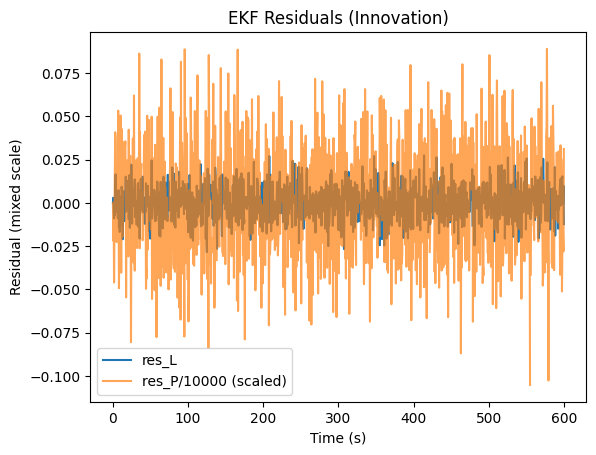

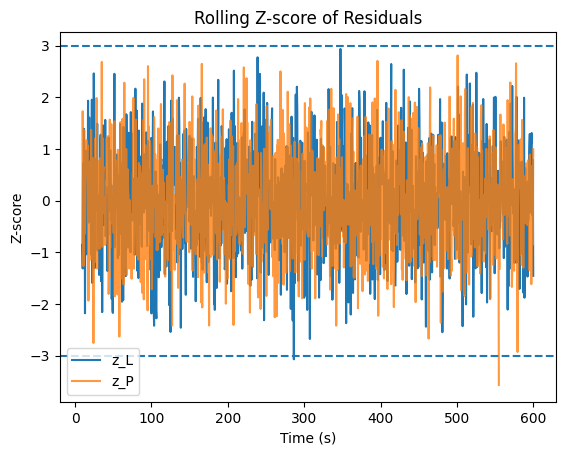

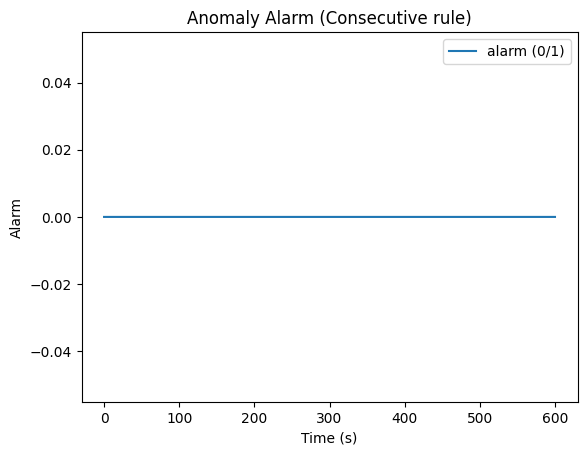

In [6]:
import matplotlib.pyplot as plt

# Residual Level
plt.figure()
plt.plot(df_anom["t_s"], df_anom["res_L"], label="res_L")
plt.plot(df_anom["t_s"], df_anom["res_P"]/10000.0, label="res_P/10000 (scaled)", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Residual (mixed scale)")
plt.title("EKF Residuals (Innovation)")
plt.legend()
plt.show()

# Z-score
plt.figure()
plt.plot(df_anom["t_s"], df_anom["z_L"], label="z_L")
plt.plot(df_anom["t_s"], df_anom["z_P"], label="z_P", alpha=0.8)
plt.axhline(3.0, linestyle="--")
plt.axhline(-3.0, linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Z-score")
plt.title("Rolling Z-score of Residuals")
plt.legend()
plt.show()

# Alarm flag
plt.figure()
plt.plot(df_anom["t_s"], df_anom["alarm"].astype(int), label="alarm (0/1)")
plt.xlabel("Time (s)")
plt.ylabel("Alarm")
plt.title("Anomaly Alarm (Consecutive rule)")
plt.legend()
plt.show()

In [7]:
alarm_times = df_anom.loc[df_anom["alarm"] == True, "t_s"]
alarm_times.head(), (alarm_times.iloc[0] if len(alarm_times) else None)

(Series([], Name: t_s, dtype: float64), None)